/home/yuchenliu/miniconda3/envs/var/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda

[constructor]  ==== flash_if_available=True (0/16), fused_if_available=True (fusing_add_ln=0/16, fusing_mlp=0/16) ==== 
    [VAR config ] embed_dim=1024, num_heads=16, depth=16, mlp_ratio=4.0
    [drop ratios ] drop_rate=0.0, attn_drop_rate=0.0, drop_path_rate=0.1 (tensor([0.0000, 0.0067, 0.0133, 0.0200, 0.0267, 0.0333, 0.0400, 0.0467, 0.0533,
        0.0600, 0.0667, 0.0733, 0.0800, 0.0867, 0.0933, 0.1000]))

[init_weights] VARGrayscale with init_std=0.0180422
✅ VQVAE loaded successfully
✅ VAR loaded successfully
Models ready for sampling!

Generating 8 grayscale MRI samples...
Level positions shape: torch.Size([1, 85, 1024]), dtype: torch.float32
Level embeddings shape: torch.Size([1, 85, 1024]), dtype: torch.float32
Positional embeddings shape: torch.Size([1, 85, 1024]), dtype: torch.float32
Level indices (lvl_1L) shape: torch.Size([1, 85]), sample values: tensor([0, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2],
       device='cuda:0')
✅ Generated imag

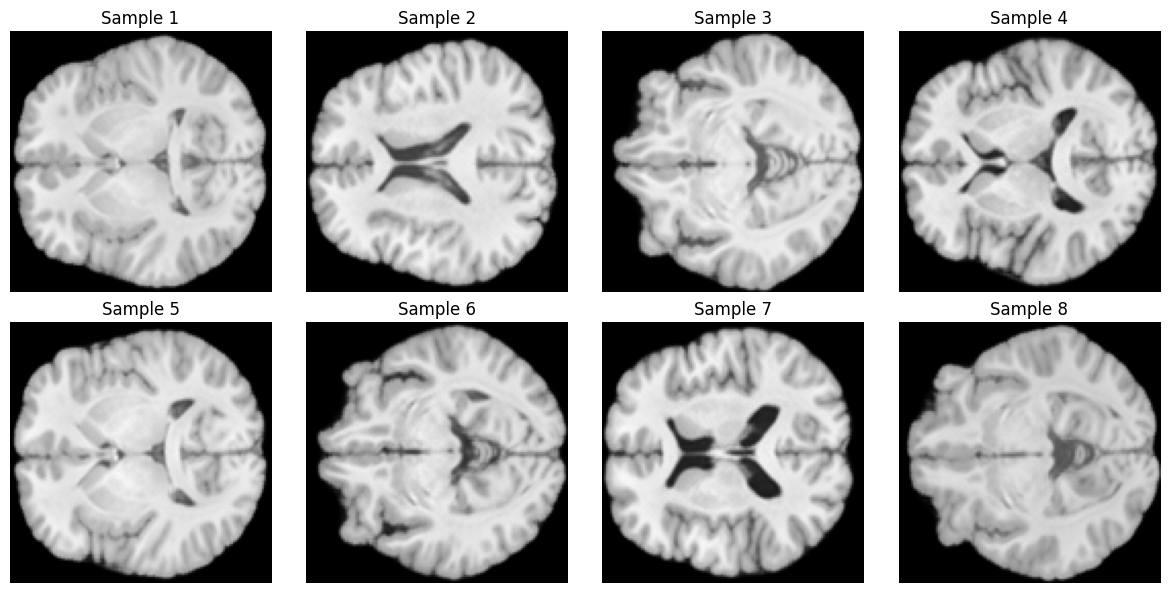

💾 Saved 8 individual samples to 'generated_samples/' directory
💾 Saved grid image as 'generated_mri_samples.png'

🎉 Sampling completed successfully!


In [1]:
import os
import os.path as osp
import torch, torchvision
import random
import numpy as np
import matplotlib.pyplot as plt
import PIL.Image as PImage, PIL.ImageDraw as PImageDraw

# Disable default parameter init for faster speed
setattr(torch.nn.Linear, 'reset_parameters', lambda self: None)
setattr(torch.nn.LayerNorm, 'reset_parameters', lambda self: None)

from models import build_vae_var_grayscale
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Build models with the exact same parameters as your training
vae, var = build_vae_var_grayscale(
    V=128,           # vocab_size to match your VQVAE
    Cvae=16,         # z_channels to match your VQVAE  
    ch=64,           # ch to match your VQVAE
    share_quant_resi=4,
    device=device, 
    patch_nums=(1, 2, 4, 8),  # Match your training patch_nums
    depth=16,        # VAR depth from your training
    shared_aln=False,
    # Optional: add these if needed for exact match
    # flash_if_available=True, 
    # fused_if_available=True,
    # init_adaln=0.5, 
    # init_adaln_gamma=1e-5, 
    # init_head=0.02, 
    # init_std=-1,
)

# print(f"Models built successfully")
# print(f"VQVAE: vocab_size={vae.vocab_size}, z_channels={vae.Cvae}")
# print(f"VAR: patch_nums={(1, 2, 4, 8)}, depth=16")

# Load your trained checkpoints
vqvae_ckpt_path = '/home/yuchenliu/VAR/local_output/vqvae_checkpoints_v128_z16_c64_b1_lpips/vqvae_epoch_190.pth'
var_ckpt_path = '/home/yuchenliu/VAR/local_output/var_custom_v128_z16_c64_b1_lpips/ar-ckpt-best.pth'

vqvae_checkpoint = torch.load(vqvae_ckpt_path, map_location='cpu')
vae.load_state_dict(vqvae_checkpoint['model_state_dict'], strict=True)
print(f"✅ VQVAE loaded successfully")
var_checkpoint = torch.load(var_ckpt_path, map_location='cpu')
var_state_dict = var_checkpoint['trainer']['var_wo_ddp']
var.load_state_dict(var_state_dict, strict=True)
print(f"✅ VAR loaded successfully")

vae.eval(), var.eval()

# Disable gradients for inference
for p in vae.parameters(): 
    p.requires_grad_(False)
for p in var.parameters(): 
    p.requires_grad_(False)
print(f"Models ready for sampling!")

# Generate grayscale MRI samples
seed = 42
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

# Sampling parameters
B = 8  # Number of samples
print(f"\nGenerating {B} grayscale MRI samples...")

with torch.inference_mode():
    with torch.autocast('cuda', enabled=True, dtype=torch.float16, cache_enabled=True):
        # Unconditional generation for grayscale images
        generated_images = var.autoregressive_infer_unconditional(
            B=B, 
            g_seed=seed, 
            top_k=50, 
            top_p=0.95, 
            more_smooth=False
        )

print(f"✅ Generated images shape: {generated_images.shape}")  # Should be [B, 1, H, W]

# Visualize results with matplotlib
plt.figure(figsize=(12, 6))
for i in range(B):
    plt.subplot(2, 4, i+1)
    # generated_images should be in range [0, 1] for grayscale
    img = generated_images[i, 0].cpu().numpy()
    plt.imshow(img, cmap='gray', vmin=0, vmax=1)
    plt.axis('off')
    plt.title(f'Sample {i+1}')

plt.tight_layout()
plt.savefig('generated_mri_samples_grid.png', dpi=150, bbox_inches='tight')
plt.show()

# Save individual samples
os.makedirs('generated_samples', exist_ok=True)
for i in range(B):
    # Convert to PIL Image and save
    img_array = generated_images[i, 0].cpu().numpy()
    # Ensure values are in [0, 1] range
    img_array = np.clip(img_array, 0, 1)
    # Convert to 0-255 range for PIL
    img_pil = PImage.fromarray((img_array * 255).astype(np.uint8), mode='L')
    img_pil.save(f'generated_samples/sample_{i+1:02d}.png')

print(f"💾 Saved {B} individual samples to 'generated_samples/' directory")

# Also create a grid image similar to your original code
if generated_images.dim() == 4 and generated_images.shape[1] == 1:
    # Convert grayscale to RGB for torchvision.utils.make_grid
    generated_rgb = generated_images.repeat(1, 3, 1, 1)  # [B, 1, H, W] -> [B, 3, H, W]
    
    chw = torchvision.utils.make_grid(generated_rgb, nrow=4, padding=2, pad_value=1.0)
    chw = chw.permute(1, 2, 0).mul_(255).cpu().numpy()
    chw = PImage.fromarray(chw.astype(np.uint8))
    chw.save('generated_mri_samples.png')
    print(f"💾 Saved grid image as 'generated_mri_samples.png'")

print(f"\n🎉 Sampling completed successfully!")

In [6]:
import os
import os.path as osp
import torch, torchvision
import random
import numpy as np
import matplotlib.pyplot as plt
import PIL.Image as PImage, PIL.ImageDraw as PImageDraw

# Disable default parameter init for faster speed
setattr(torch.nn.Linear, 'reset_parameters', lambda self: None)
setattr(torch.nn.LayerNorm, 'reset_parameters', lambda self: None)

from models import build_vae_var_grayscale
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

# Build models with the exact same parameters as your training
vae, var = build_vae_var_grayscale(
    V=128,           # vocab_size to match your VQVAE
    Cvae=16,         # z_channels to match your VQVAE  
    ch=64,           # ch to match your VQVAE
    share_quant_resi=4,
    device=device, 
    patch_nums=(1, 2, 4, 8),  # Match your training patch_nums
    depth=16,        # VAR depth from your training
    shared_aln=False,
    # Optional: add these if needed for exact match
    # flash_if_available=True, 
    # fused_if_available=True,
    # init_adaln=0.5, 
    # init_adaln_gamma=1e-5, 
    # init_head=0.02, 
    # init_std=-1,
)

# print(f"Models built successfully")
# print(f"VQVAE: vocab_size={vae.vocab_size}, z_channels={vae.Cvae}")
# print(f"VAR: patch_nums={(1, 2, 4, 8)}, depth=16")

# Load your trained checkpoints
vqvae_ckpt_path = '/home/yuchenliu/VAR/local_output/vqvae_checkpoints_v128_z16_c64_b1_lpips/vqvae_epoch_190.pth'
var_ckpt_path = '/home/yuchenliu/VAR/local_output/var_custom_v128_z16_c64_b1_lpips/ar-ckpt-best.pth'

vqvae_checkpoint = torch.load(vqvae_ckpt_path, map_location='cpu')
vae.load_state_dict(vqvae_checkpoint['model_state_dict'], strict=True)
print(f"✅ VQVAE loaded successfully")
var_checkpoint = torch.load(var_ckpt_path, map_location='cpu')
var_state_dict = var_checkpoint['trainer']['var_wo_ddp']
var.load_state_dict(var_state_dict, strict=True)
print(f"✅ VAR loaded successfully")

vae.eval(), var.eval()

# Disable gradients for inference
for p in vae.parameters(): 
    p.requires_grad_(False)
for p in var.parameters(): 
    p.requires_grad_(False)
print(f"Models ready for sampling!")

# Generate grayscale MRI samples
seed = 42
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)

# Sampling parameters
B = 8  # Number of samples
print(f"\nGenerating {B} grayscale MRI samples...")

with torch.inference_mode():
    # Load and preprocess a test MRI image (without autocast to avoid dtype issues)
    test_image_path = "/home/yuchenliu/Dataset/IXI/train_val_test_split/test/mid_brain/IXI012-HH-1211_t1_slice072.npy"
    
    # Load the numpy array
    original_img_np = np.load(test_image_path)
    print(f"Loaded image shape: {original_img_np.shape}, dtype: {original_img_np.dtype}")
    print(f"Image range: [{original_img_np.min():.4f}, {original_img_np.max():.4f}]")
    
    # Normalize to [0, 1] range if needed
    if original_img_np.max() > 1.0:
        original_img_np = original_img_np / original_img_np.max()
    
    # Convert to PyTorch tensor and add batch and channel dimensions
    # Shape: (H, W) -> (1, 1, H, W)
    original_img = torch.from_numpy(original_img_np).unsqueeze(0).unsqueeze(0).float().to(device)
    print(f"Preprocessed tensor shape: {original_img.shape}")
    
    # Convert image to normalized range [-1, 1] for VAE
    original_img_normalized = original_img * 2.0 - 1.0
    
    # Tokenize the original image
    input_img_tokens = vae.img_to_idxBl(original_img_normalized, var.patch_nums)
    print(f"Tokenized image with {len(input_img_tokens)} scale levels")
    
    # Create inpainting mask - mask out center region for inpainting
    # Parameters: y0, x0 (top-left), y1, x1 (bottom-right) in normalized coordinates [0, 1]
    inpaint_mask = var.get_inpainting_mask(
        var.patch_nums,
        y0=0.3, x0=0.3,  # Top-left of region to inpaint
        y1=0.7, x1=0.7,  # Bottom-right of region to inpaint  
        device=device
    )
    print(f"Created inpainting mask with shape: {inpaint_mask.shape}")
    
    # Create masked version for visualization
    mask_viz = torch.nn.functional.interpolate(
        inpaint_mask.unsqueeze(0).unsqueeze(0).float(), 
        size=original_img.shape[-2:], 
        mode='bilinear', 
        align_corners=False
    ).squeeze()
    
    # Apply mask to original image (set masked region to 0)
    masked_img = original_img.squeeze() * mask_viz
    
    # Perform inpainting
    print("Starting inpainting...")
    inpainted_img = var.autoregressive_infer_inpainting(
        B=1, 
        input_img_tokens=input_img_tokens,
        edit_mask=inpaint_mask,
        g_seed=42,
        top_k=900, 
        top_p=0.95
    )
    
    print(f"Inpainting completed! Output shape: {inpainted_img.shape}")
    
    # Convert tensors to numpy for visualization
    original_np = original_img.squeeze().cpu().numpy()
    masked_np = masked_img.cpu().numpy()
    inpainted_np = inpainted_img.squeeze().cpu().numpy()
    mask_np = (1 - mask_viz).cpu().numpy()  # Show inpainted region in white
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    fig.suptitle('MRI Inpainting Results', fontsize=16)
    
    # Original image
    axes[0, 0].imshow(original_np, cmap='gray', vmin=0, vmax=1)
    axes[0, 0].set_title('Original Image')
    axes[0, 0].axis('off')
    
    # Mask visualization (white = region to inpaint)
    axes[0, 1].imshow(mask_np, cmap='gray', vmin=0, vmax=1)
    axes[0, 1].set_title('Inpainting Mask (White = Generate)')
    axes[0, 1].axis('off')
    
    # Masked image
    axes[1, 0].imshow(masked_np, cmap='gray', vmin=0, vmax=1)
    axes[1, 0].set_title('Masked Image (Input)')
    axes[1, 0].axis('off')
    
    # Inpainted result
    axes[1, 1].imshow(inpainted_np, cmap='gray', vmin=0, vmax=1)
    axes[1, 1].set_title('Inpainted Result')
    axes[1, 1].axis('off')
    
    plt.tight_layout()
    
    # Save the results
    output_path = '/home/yuchenliu/VAR/mri_inpainting_result.png'
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Results saved to: {output_path}")
    
    # Also save individual images
    from PIL import Image
    
    # Save original
    orig_pil = Image.fromarray((original_np * 255).astype(np.uint8), mode='L')
    orig_pil.save('/home/yuchenliu/VAR/mri_original.png')
    
    # Save masked
    masked_pil = Image.fromarray((masked_np * 255).astype(np.uint8), mode='L')
    masked_pil.save('/home/yuchenliu/VAR/mri_masked.png')
    
    # Save inpainted
    inpainted_pil = Image.fromarray((inpainted_np * 255).astype(np.uint8), mode='L')
    inpainted_pil.save('/home/yuchenliu/VAR/mri_inpainted.png')
    
    # Save mask
    mask_pil = Image.fromarray((mask_np * 255).astype(np.uint8), mode='L')
    mask_pil.save('/home/yuchenliu/VAR/mri_mask.png')
    
    print("Individual images saved:")
    print("- mri_original.png")
    print("- mri_masked.png") 
    print("- mri_inpainted.png")
    print("- mri_mask.png")
    
    plt.show()
    
    # Print some statistics
    print(f"\nImage Statistics:")
    print(f"Original image range: [{original_np.min():.4f}, {original_np.max():.4f}]")
    print(f"Inpainted image range: [{inpainted_np.min():.4f}, {inpainted_np.max():.4f}]")
    print(f"Mask covers {(1-mask_viz).sum().item() / mask_viz.numel() * 100:.1f}% of the image")



Using device: cuda

[constructor]  ==== flash_if_available=True (0/16), fused_if_available=True (fusing_add_ln=0/16, fusing_mlp=0/16) ==== 
    [VAR config ] embed_dim=1024, num_heads=16, depth=16, mlp_ratio=4.0
    [drop ratios ] drop_rate=0.0, attn_drop_rate=0.0, drop_path_rate=0.1 (tensor([0.0000, 0.0067, 0.0133, 0.0200, 0.0267, 0.0333, 0.0400, 0.0467, 0.0533,
        0.0600, 0.0667, 0.0733, 0.0800, 0.0867, 0.0933, 0.1000]))

[init_weights] VARGrayscale with init_std=0.0180422
✅ VQVAE loaded successfully
✅ VAR loaded successfully
Models ready for sampling!

Generating 8 grayscale MRI samples...
Loaded image shape: (128, 128), dtype: float32
Image range: [0.0000, 0.9922]
Preprocessed tensor shape: torch.Size([1, 1, 128, 128])
Tokenized image with 4 scale levels


AttributeError: 'VARGrayscale' object has no attribute 'get_inpainting_mask'